# Dynare Frontier Macroeconomic Toolbox — 2.0 & 2.1 Showcase

**Can we run state-of-the-art macroeconomic DSGE modeling entirely in pure Python, without MATLAB, Dynare C++ compilation, or proprietary software?**

Dynare is the standard platform for solving, simulating, and estimating dynamic stochastic general equilibrium (DSGE) models. However, its traditional workflow requires MATLAB or Octave licenses and C++ MEX compilation.

With **puremacro 2.0 and 2.1**, researchers and students can parse standard Dynare `.mod` files directly, solve 1st and pruned 2nd-order perturbations, compute Forecast Error Variance Decompositions (FEVD), conduct Historical Shock Decompositions, solve occasionally binding constraints (OccBin / ZLB), execute deterministic non-linear perfect foresight simulations, and perform full Bayesian MCMC estimation—all in **100% pure Python** running on laptops, tablets, and zero-install browsers via WebAssembly.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

_cwd = Path.cwd()
sys.path.insert(0, str(_cwd if (_cwd / "_nbstyle.py").exists() else _cwd / "notebooks"))
import _nbstyle
_nbstyle.apply_style()

from puremacro.dsge import (
    load_mod,
    build_dynare,
    compute_fevd,
    compute_shock_decomposition,
    solve_occbin,
    OccBinConstraint,
    solve_perfect_foresight,
)

## 1. Reading and Solving Pfeifer's Smets-Wouters (2007) Model (.mod)

We load Johannes Pfeifer's canonical Smets & Wouters (2007, *AER*) model file directly (`sw07_pfeifer.mod`).
`puremacro.dsge.load_mod` parses all declarations, model equations, steady-state relationships, and shocks blocks, automatically identifying the 15 predetermined state variables and 25 forward-looking controls.

Endogenous variables : 40
Exogenous shocks     : 7
Predetermined states : 15
Forward-looking jumps: 25


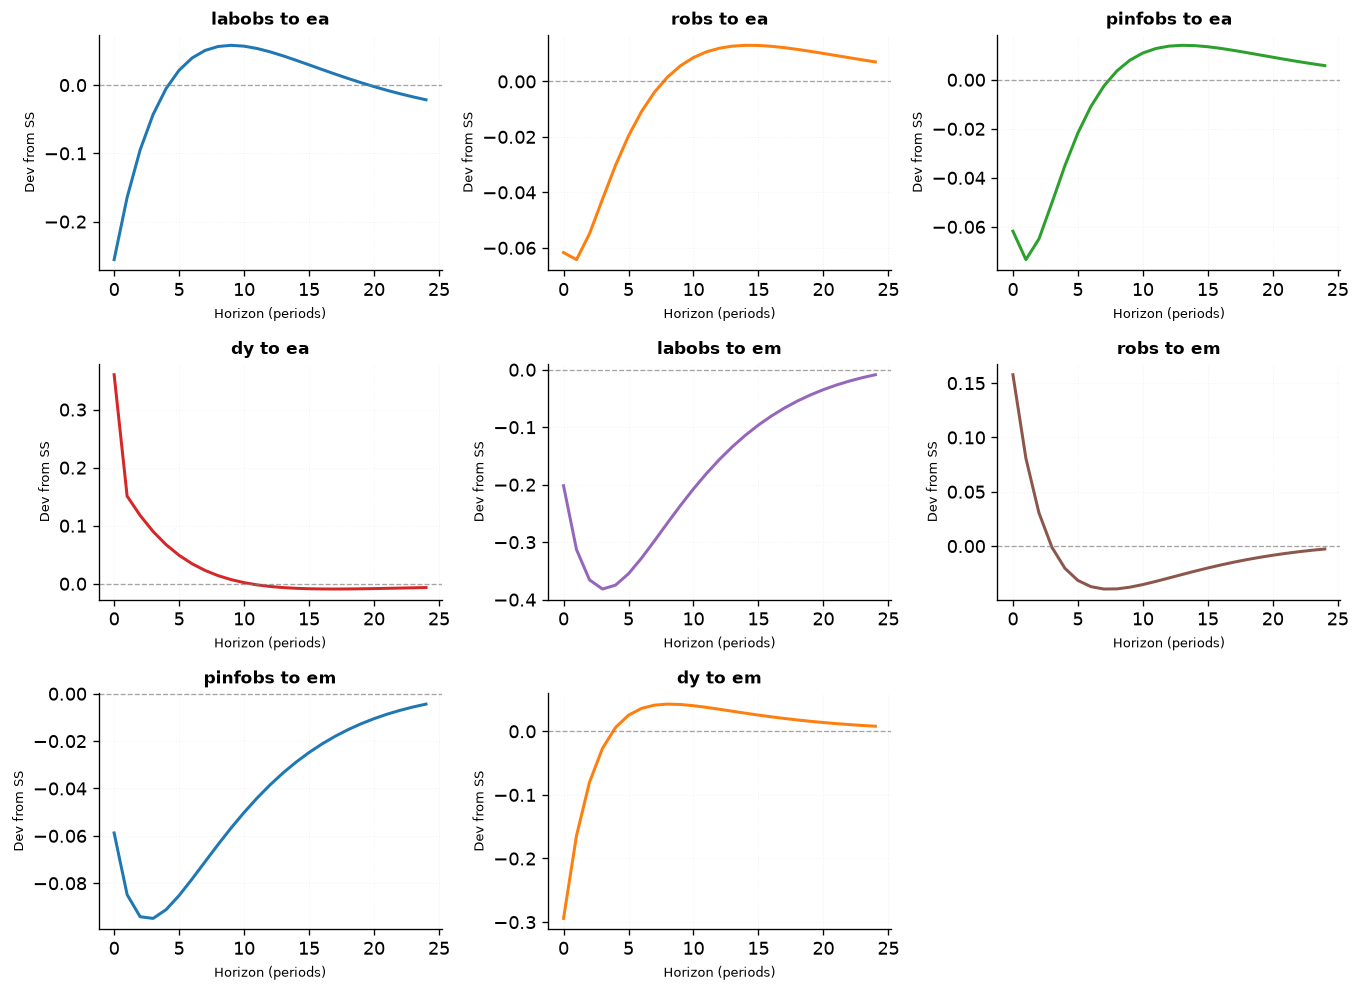

In [2]:
import puremacro.dsge
# Resolve the reference .mod from the installed package so the notebook runs
# from any working directory (tools/build_notebooks.py uses notebooks/ as cwd).
mod_path = Path(puremacro.dsge.__file__).parent / "_references" / "sw07_pfeifer.mod"
m = load_mod(mod_path, order=1)

print(f"Endogenous variables : {len(m.variables)}")
print(f"Exogenous shocks     : {len(m.shocks)}")
print(f"Predetermined states : {m.n_states}")
print(f"Forward-looking jumps: {m.n_controls}")

# Execute stoch_simul to compute decision rules, theoretical moments, and IRFs
sim_res = m.stoch_simul(irf=24)
fig_irfs = sim_res.plot(variables=["labobs", "robs", "pinfobs", "dy"], shocks=["ea", "em"])
plt.show()

## 2. Forecast Error Variance Decomposition (FEVD)

The Forecast Error Variance Decomposition quantifies the percentage contribution of each structural innovation to the variance of forecast errors across horizons $h \in \{1, 4, 8, 16, \dots, \infty\}$.

By the orthogonal VMA representation:
$$ y_{t+h} - \mathbb{E}_t y_{t+h} = \sum_{k=0}^{h-1} \Psi_k u_{t+h-k} $$
$$ \text{MSE}_i(h) = \sum_{j} \sum_{k=0}^{h-1} (\Psi_k[i, j])^2 \sigma_j^2 $$
Puremacro guarantees within machine precision that variance shares sum strictly to 1.0 (100%) for all variables and horizons.

FORECAST ERROR VARIANCE DECOMPOSITION (Dynare Format)
                         ea        eb        eg       eqs        em     epinf        ew
Variable Horizon                                                                       
labobs   1         0.003423  0.978959  0.009319  0.006104  0.002133  0.000012  0.000050
robs     1         0.001503  0.987040  0.000353  0.001083  0.009794  0.000092  0.000136
pinfobs  1         0.016270  0.824805  0.000605  0.011356  0.014732  0.124856  0.007377
dy       1         0.003297  0.979260  0.008959  0.006114  0.002204  0.000115  0.000052
dc       1         0.000856  0.996891  0.000388  0.000019  0.001821  0.000024  0.000001
dinve    1         0.000508  0.847182  0.000024  0.148656  0.003495  0.000126  0.000010
dw       1         0.023802  0.622587  0.000047  0.004116  0.004165  0.073775  0.271506
ewma     1         0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  1.000000
epinfma  1         0.000000  0.000000  0.000000  0.000000  0.00000

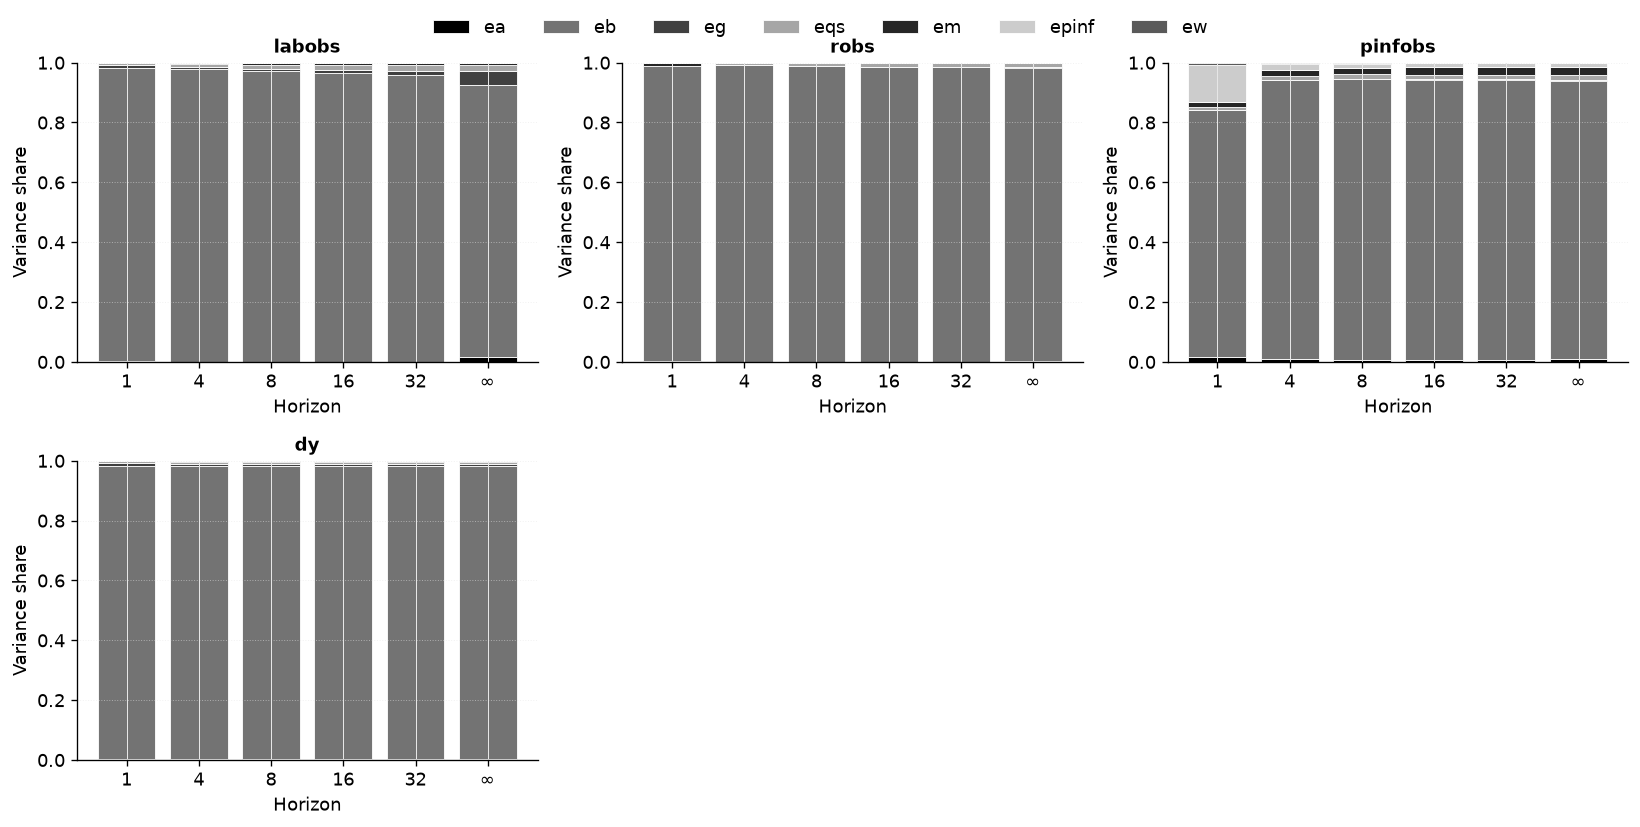

In [3]:
fevd_res = compute_fevd(m, horizons=[1, 4, 8, 16, 32, None])
print(fevd_res.summary())

# Plot variance shares
fig_fevd = fevd_res.plot(variables=["labobs", "robs", "pinfobs", "dy"])
plt.show()

## 3. Historical Shock Decomposition

Which historical shocks drove business cycle fluctuations?
Using the Kalman smoother, puremacro reconstructs the trajectory of each observable variable into components explained by:
1. Steady state $\bar{y}$
2. Initial state decay $C A^t s_0$
3. Individual structural shock paths $\sum_j \text{Shock}_j(t)$

Loaded 156 historical quarters for observables: ['dy', 'dc', 'dinve', 'labobs', 'pinfobs', 'dw', 'robs']
Smoothed states shape : (156, 15) (quarters x states)
Smoothed shocks shape : (156, 7) (quarters x shocks)
Decomposition variables: ['labobs', 'robs', 'pinfobs', 'dy', 'dc', 'dinve', 'dw', 'ewma', 'epinfma', 'zcapf', 'rkf', 'kf', 'pkf', 'cf', 'invef', 'yf', 'labf', 'wf', 'rrf', 'mc', 'zcap', 'rk', 'k', 'pk', 'c', 'inve', 'y', 'lab', 'pinf', 'w', 'r', 'a', 'b', 'g', 'qs', 'ms', 'spinf', 'sw', 'kpf', 'kp']


/Users/jalonso/Documents/RESEARCH/puremacro/puremacro/dsge/_results.py:692: UserWarning: compute_shock_decomposition: the smoothed model path does not reproduce the observed data for dinve (max|residual|=2.595e+00 vs series range 1.845e+01), labobs (max|residual|=1.787e+00 vs series range 1.037e-01), robs (max|residual|=7.501e-01 vs series range 2.391e+00), dw (max|residual|=6.777e-01 vs series range 2.391e+00), dy (max|residual|=5.445e-01 vs series range 2.962e+00) (+2 more). The shock contributions, the initial condition and the steady state therefore do not add up to 'actual' on their own; the gap is reported in the 'residual' column. This is expected when there are more observed series than structural shocks, and a sign of misspecification otherwise.
  return compute_shock_decomposition(self._model, self._data, **kwargs)


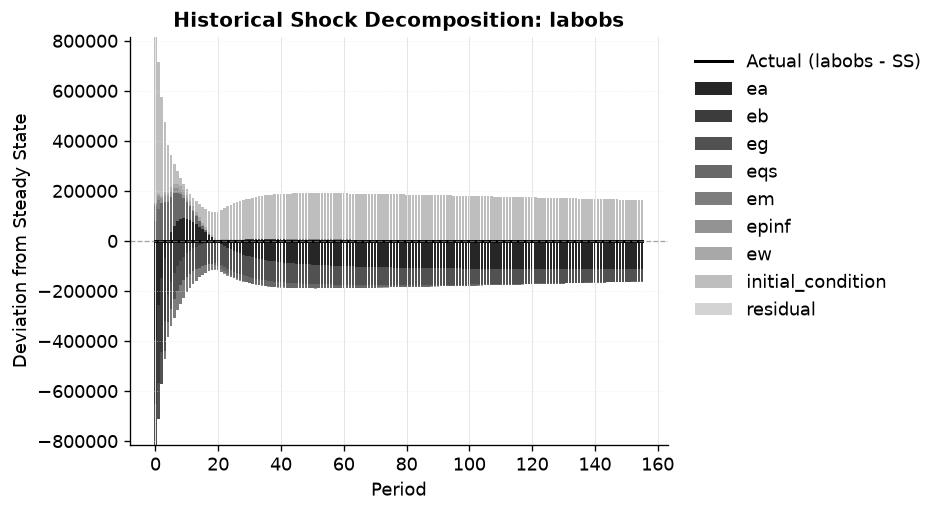

In [4]:
# Load canonical Smets-Wouters (2007) historical data for US business cycles
csv_path = Path(puremacro.dsge.__file__).parent / "_sw07_data.csv"
raw_data = pd.read_csv(csv_path, comment="#")
rename_map = {
    "gdp_growth": "dy",
    "cons_growth": "dc",
    "inv_growth": "dinve",
    "wage_growth": "dw",
    "log_hours": "labobs",
    "infl": "pinfobs",
    "ffr": "robs",
}
data = raw_data.rename(columns=rename_map)[list(m._varobs)]
print(f"Loaded {data.shape[0]} historical quarters for observables: {list(data.columns)}")

# Kalman smoother: extract smoothed unobserved states and structural innovations
sm_res = m.smoother(data)
print(f"Smoothed states shape : {sm_res.states.shape} (quarters x states)")
print(f"Smoothed shocks shape : {sm_res.shocks.shape} (quarters x shocks)")

# Historical shock decomposition directly on real US data
decomp_res = sm_res.shock_decomposition()
print(f"Decomposition variables: {decomp_res.variable_names}")

fig_decomp = decomp_res.plot(variable="labobs")
plt.show()

## 4. Occasionally Binding Constraints & Zero Lower Bound (OccBin)

When nominal interest rates hit the Zero Lower Bound ($r_t \ge -r_{ss}$), the linear approximation breaks down.
Following Guerrieri & Iacoviello (2015, *JME*), `puremacro.dsge.solve_occbin` solves the piecewise-linear model via backward-forward regime iterations.

Under normal times, monetary policy follows a standard Taylor rule:
$$ r_t = \phi_\pi \pi_t + \phi_y y_t + \varepsilon_{r,t} $$
When the constraint binds, the nominal rate is clamped to the floor:
$$ r_t = -r_{ss} $$

OCCASIONALLY BINDING CONSTRAINTS REPORT (OccBin - Guerrieri & Iacoviello 2015)
Constraint         : OccBinConstraint(r < -0.01)
Algorithm status   : Converged in 2 iteration(s)
Binding duration   : 5 period(s) out of 40
Regime sequence    : [1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]...
------------------------------------------------------------------------------
TRAJECTORY SUMMARY STATISTICS
------------------------------------------------------------------------------
    Impact (t=1)       Min       Max      Mean  Final (t=H)
y      -0.071794 -0.071794 -0.000005 -0.005738    -0.000005
pi     -0.022318 -0.022318 -0.000002 -0.002150    -0.000002
r      -0.010000 -0.010000 -0.000004 -0.002297    -0.000004
g      -0.020000 -0.020000 -0.000003 -0.002500    -0.000003


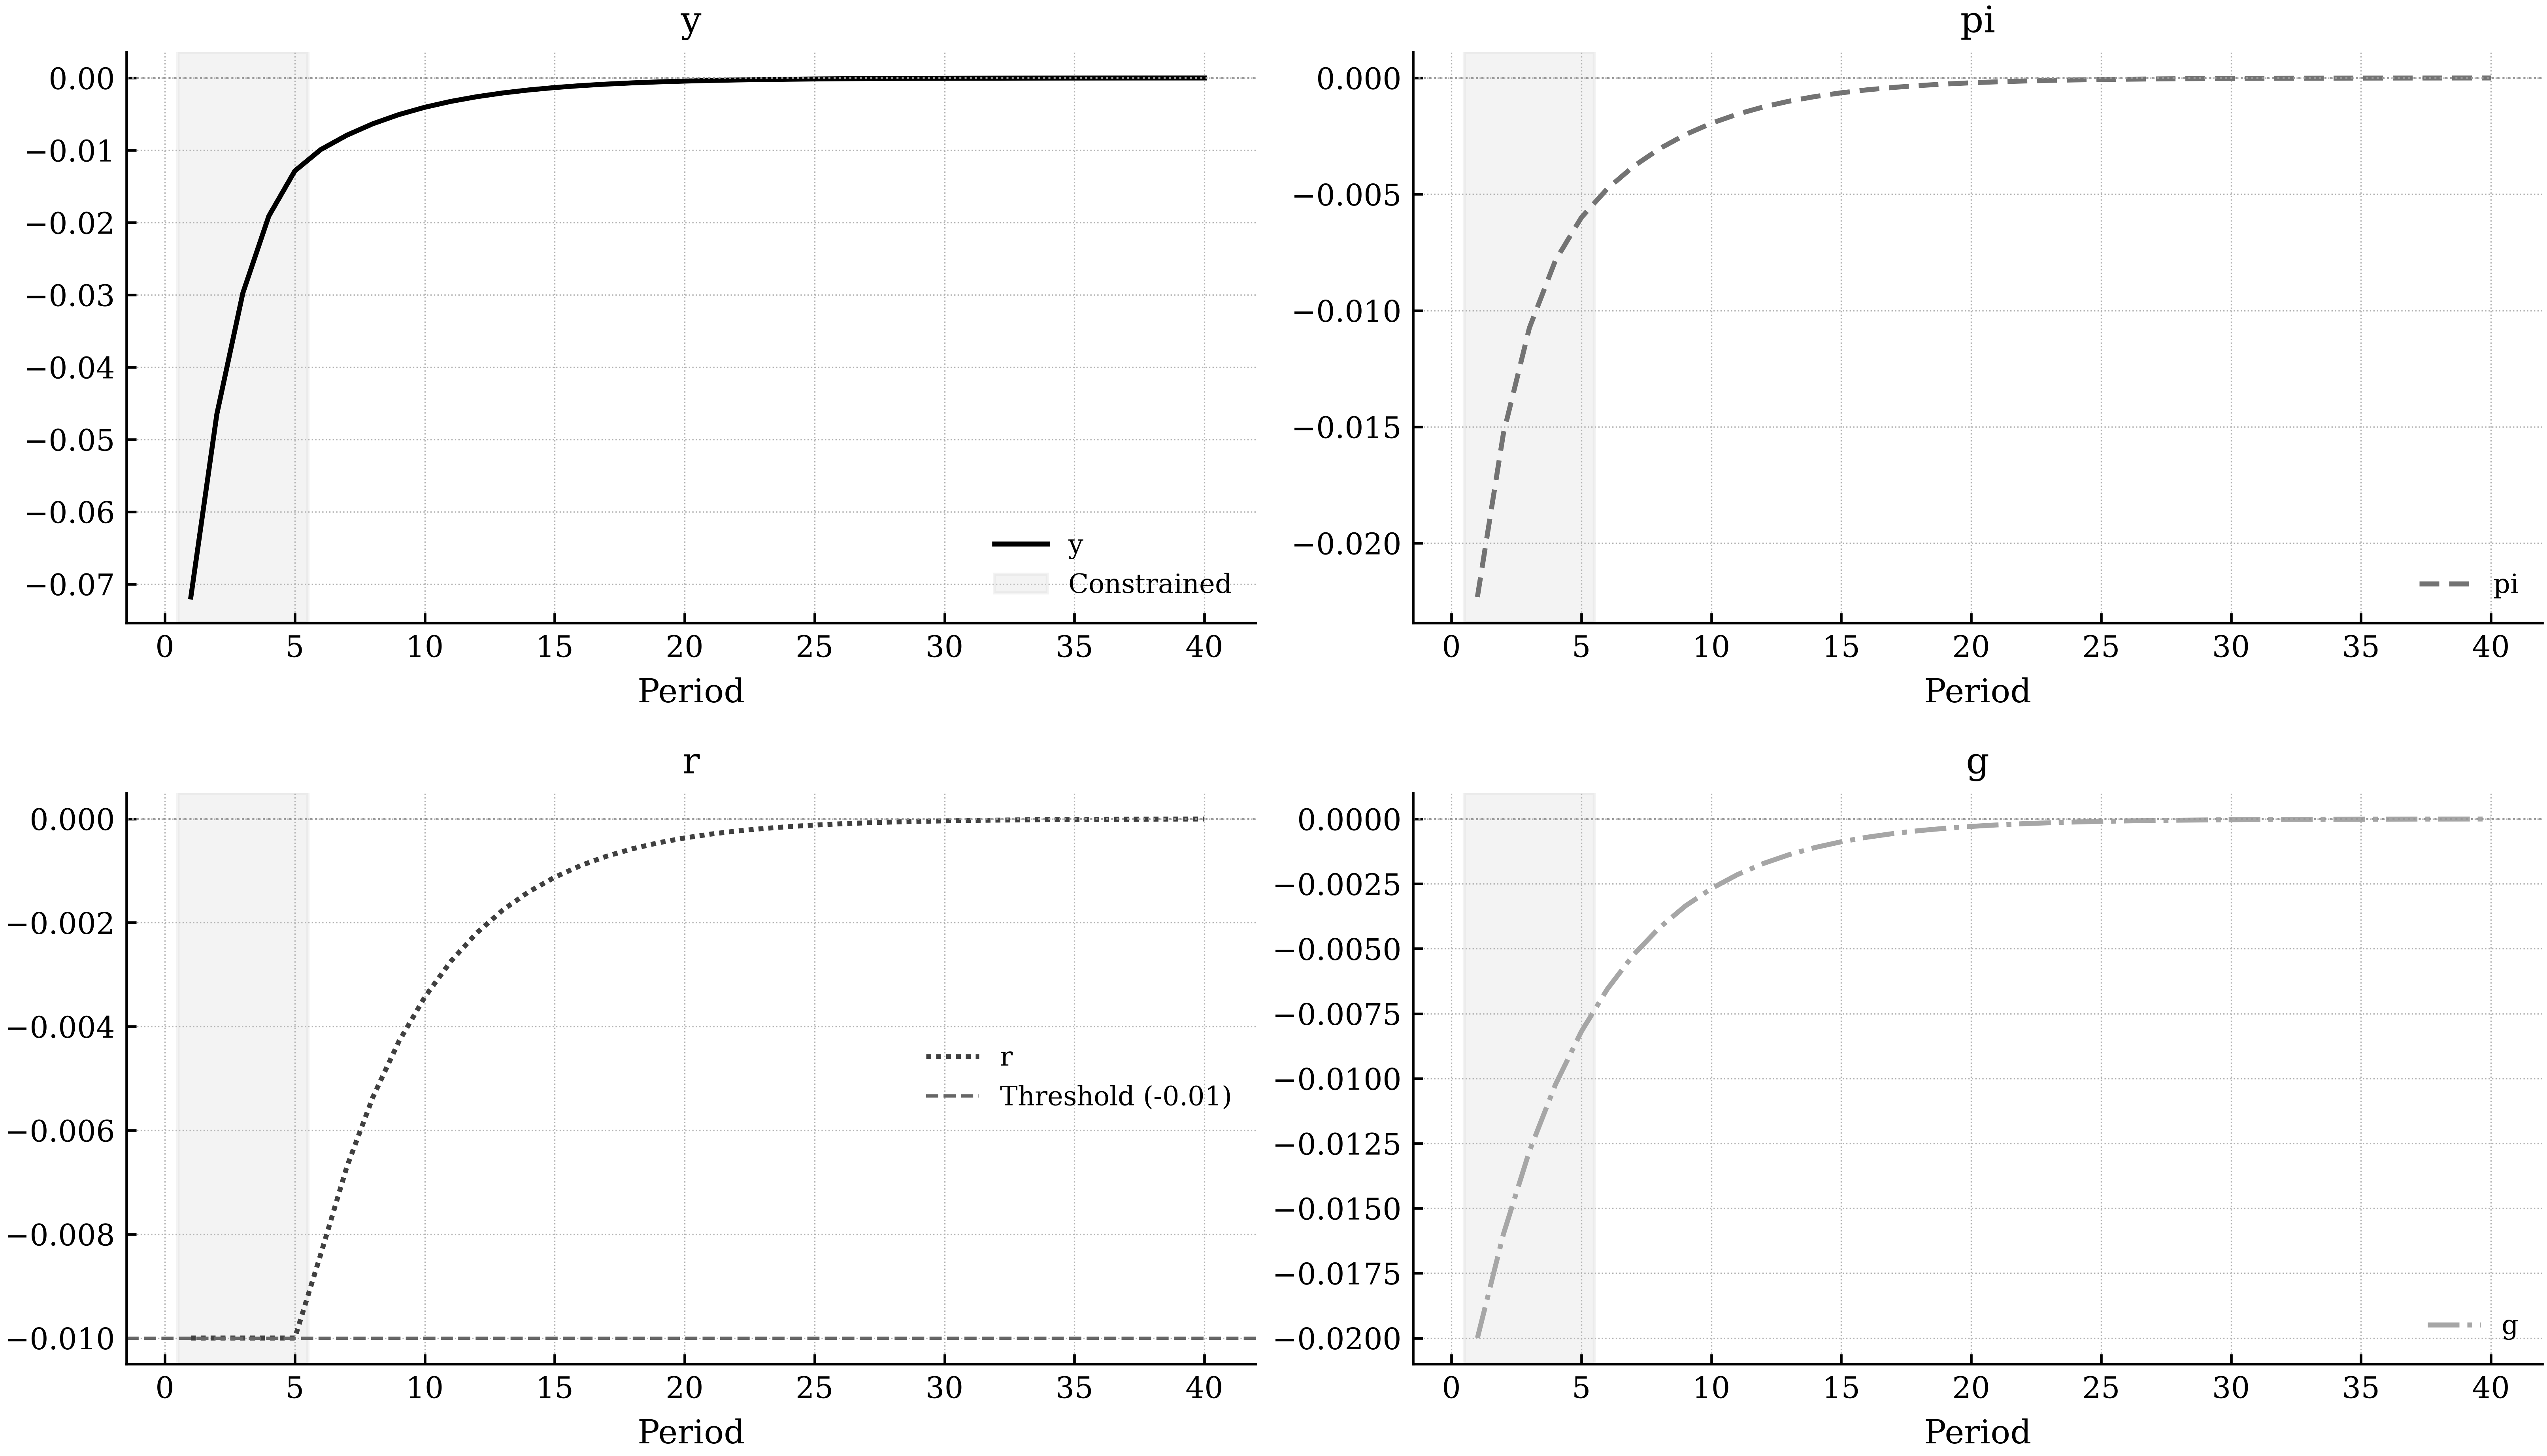

In [5]:
params_nk = {
    "beta": 0.99,
    "sigma": 1.0,
    "kappa": 0.1,
    "phi_pi": 1.5,
    "phi_y": 0.125,
    "rho_g": 0.8,
    "r_ss": 0.01,
}
variables_nk = ["y", "pi", "r", "g"]
shocks_nk = ["eps_r", "eps_g"]
ss_nk = {v: 0.0 for v in variables_nk}

def nk_ref(lead, curr, lag, shocks_v, p):
    return [
        curr.y - lead.y + (curr.r - lead.pi) / p.sigma - curr.g,
        curr.pi - p.beta * lead.pi - p.kappa * curr.y,
        curr.r - p.phi_pi * curr.pi - p.phi_y * curr.y - shocks_v.eps_r,
        curr.g - p.rho_g * lag.g - shocks_v.eps_g,
    ]

def nk_cons(lead, curr, lag, shocks_v, p):
    return [
        curr.y - lead.y + (curr.r - lead.pi) / p.sigma - curr.g,
        curr.pi - p.beta * lead.pi - p.kappa * curr.y,
        curr.r - (-p.r_ss),
        curr.g - p.rho_g * lag.g - shocks_v.eps_g,
    ]

ref_mod = build_dynare(nk_ref, variables=variables_nk, shocks=shocks_nk, params=params_nk, steady_state=ss_nk)
cons_mod = build_dynare(nk_cons, variables=variables_nk, shocks=shocks_nk, params=params_nk, steady_state=ss_nk, check_steady_state=False, strict=False)

constraint = OccBinConstraint(variable="r", threshold=-params_nk["r_ss"], operator="<")
shock_seq = np.array([0.0, -0.020])

occ_res = solve_occbin(ref_mod, cons_mod, constraint, shock_sequence=shock_seq, horizon=40)
print(occ_res.summary())

fig_occ = occ_res.plot()
plt.show()

## 5. Deterministic Non-Linear Simulation / Perfect Foresight

For large transitions far from the steady state (e.g. demographic shifts, green transition, sovereign debt restructurings), linear perturbation is inaccurate.
`puremacro.dsge.solve_perfect_foresight` implements the stacked Newton-Raphson algorithm (Boucekkine 1995, Juillard 1996) with sparse block-tridiagonal Jacobian inversion.

We simulate the non-linear Ramsey neoclassical growth model starting from depressed capital $k_0 = 0.5 \cdot k_{ss}$:
$$ c_t^{-\sigma} = \beta c_{t+1}^{-\sigma} (\alpha A_t k_t^{\alpha - 1} + 1 - \delta) $$
$$ k_t = A_t k_{t-1}^\alpha + (1-\delta) k_{t-1} - c_t $$

PERFECT FORESIGHT SIMULATION RESULT
Convergence status  : CONVERGED
Iterations          : 6
Residual norm       : 1.7764e-15  (initial guess: 1.8448e-01)
Terminal error      : 2.1640e-03
Simulation horizon  : 60 periods
Endogenous variables: y_0, y_1
------------------------------------------------------------------------
TRAJECTORY SUMMARY (t=1..T):
         mean       std       min       max   initial  terminal
y_0  1.225387  0.093942  0.878341  1.279941  0.878341  1.279941
y_1  4.153134  0.472062  2.461684  4.431711  2.461684  4.431672


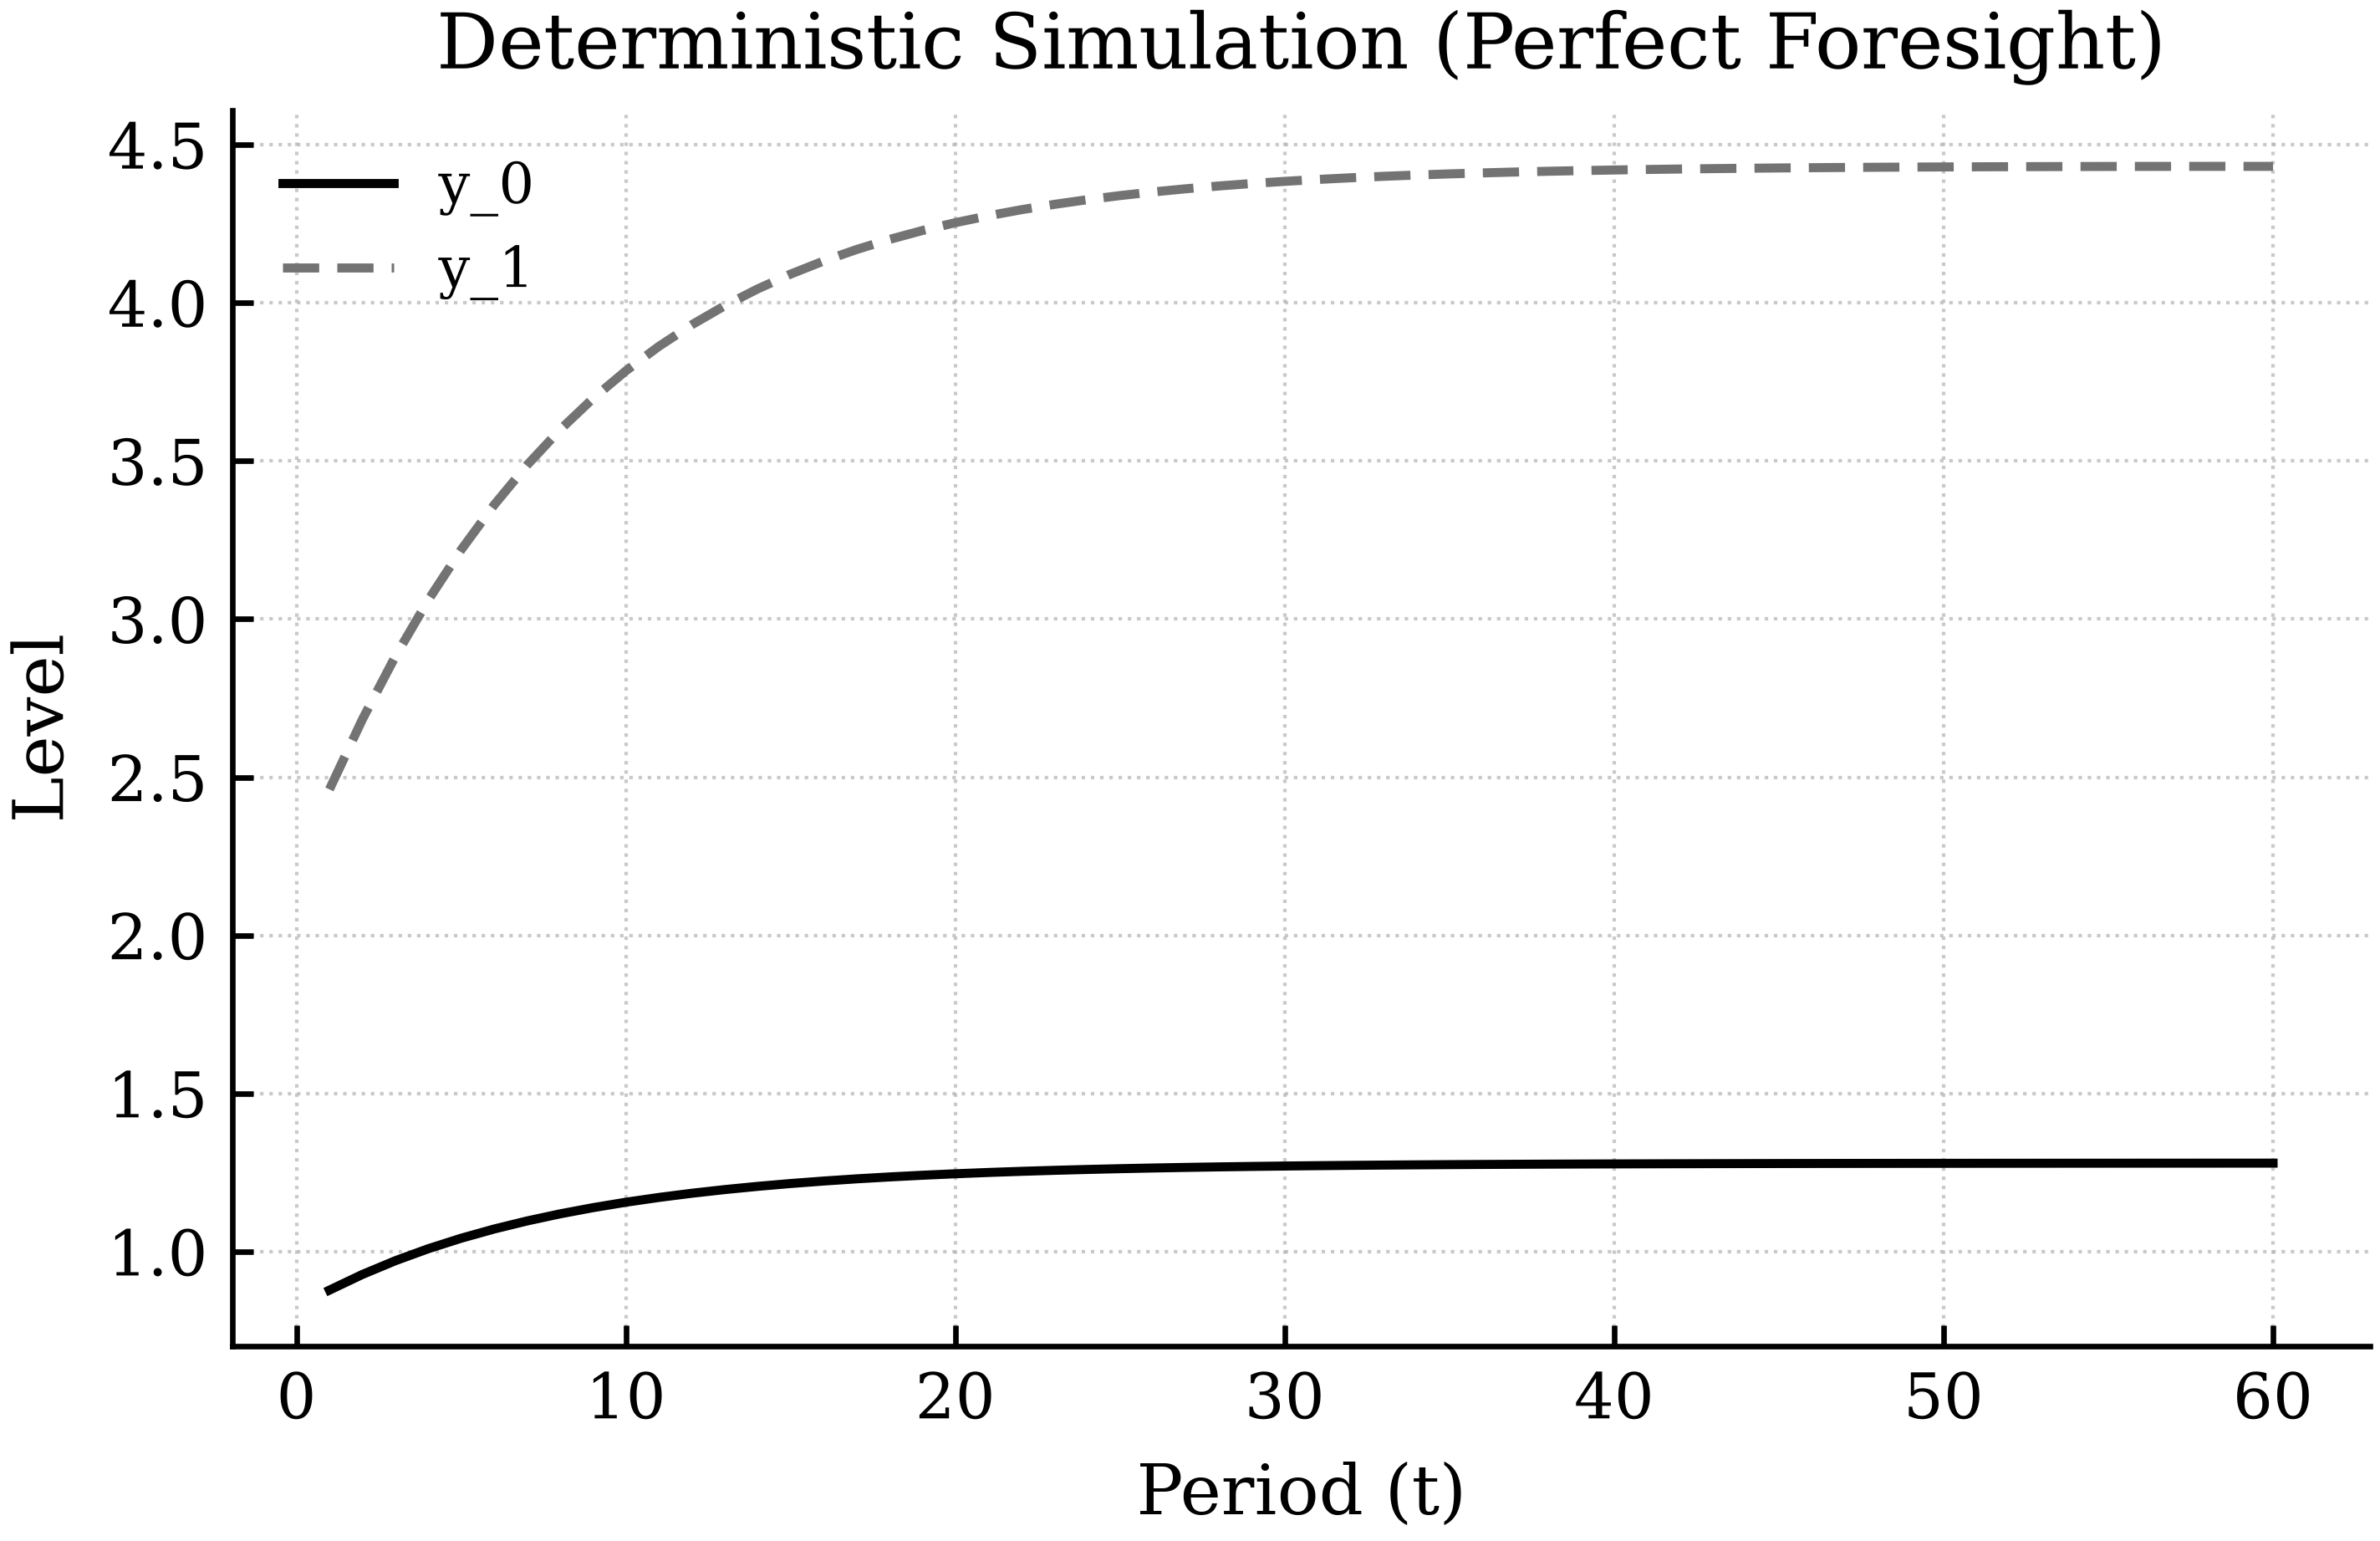

In [6]:
alpha, beta, delta, sigma = 0.33, 0.96, 0.08, 1.0
k_ss = ((1.0 / beta - (1.0 - delta)) / alpha) ** (1.0 / (alpha - 1.0))
c_ss = k_ss ** alpha - delta * k_ss
y_ss = np.array([c_ss, k_ss])

def ramsey_eqs(lead, curr, lag, exo):
    c_t, k_t = curr[0], curr[1]
    c_p, k_p = lead[0], lead[1]
    k_m = lag[1]
    A_t = exo[0]
    
    euler = c_t ** (-sigma) - beta * (c_p ** (-sigma)) * (alpha * A_t * (k_t ** (alpha - 1.0)) + 1.0 - delta)
    resource = k_t - (A_t * (k_m ** alpha) + (1.0 - delta) * k_m - c_t)
    return np.array([euler, resource])

y_init = np.array([c_ss * 0.7, 0.5 * k_ss])
exo_path = np.ones((60, 1))

pf_res = solve_perfect_foresight(ramsey_eqs, y_init=y_init, y_ss=y_ss, exogenous_path=exo_path, n_periods=60)
print(pf_res.summary())

fig_pf = pf_res.plot()
plt.show()

## 6. Bayesian DSGE Estimation via Random Walk Metropolis-Hastings

puremacro 2.6.0 estimates `.mod` models natively using their declared priors (`estimated_params`) and observables (`varobs`).
Calling `m.estimate(data)` evaluates the exact state-space log-likelihood via the Kalman filter and executes Random Walk Metropolis-Hastings MCMC sampling.

/Users/jalonso/Documents/RESEARCH/puremacro/puremacro/dsge/estimate.py:587: UserWarning: estimate_dsge: the mode search terminated at the starting point without moving ("mode search skipped (method='none')"); initial_params is being reported as the mode but has NOT been shown to be one. Supply a better initial_params, or treat `mode` and `mode_hessian_inv` as descriptive only.
  warnings.warn(


/Users/jalonso/Documents/RESEARCH/puremacro/puremacro/dsge/estimate.py:706: UserWarning: estimate_dsge: chain 0 accept_rate=0.525 outside [0.10, 0.50]; mixing may be poor.
  warnings.warn(


                mean       std        q5       q50       q95      mode
SE_ea       0.565648  0.060870  0.495304  0.552475  0.665061  0.461800
SE_eb       0.248993  0.042857  0.185388  0.249326  0.314121  0.181851
SE_eg       0.504916  0.037681  0.452150  0.500185  0.567145  0.609000
SE_eqs      0.558352  0.096283  0.432124  0.560874  0.708984  0.460170
SE_em       0.351303  0.104575  0.204007  0.312837  0.517358  0.239700
SE_epinf    0.265361  0.025623  0.227279  0.265595  0.304872  0.145500
SE_ew       0.348661  0.060834  0.227968  0.364021  0.432954  0.208900
crhoa       0.968806  0.013817  0.953337  0.966870  0.988594  0.967600
crhob       0.272529  0.008595  0.262600  0.274153  0.282488  0.270300
crhog       0.986785  0.004286  0.979723  0.986977  0.991895  0.993000
crhoqs      0.570205  0.007709  0.559377  0.570483  0.581543  0.572400
crhoms      0.309139  0.004036  0.303453  0.309984  0.316589  0.300000
crhopinf    0.859802  0.004117  0.851496  0.861342  0.864708  0.869200
crhow 

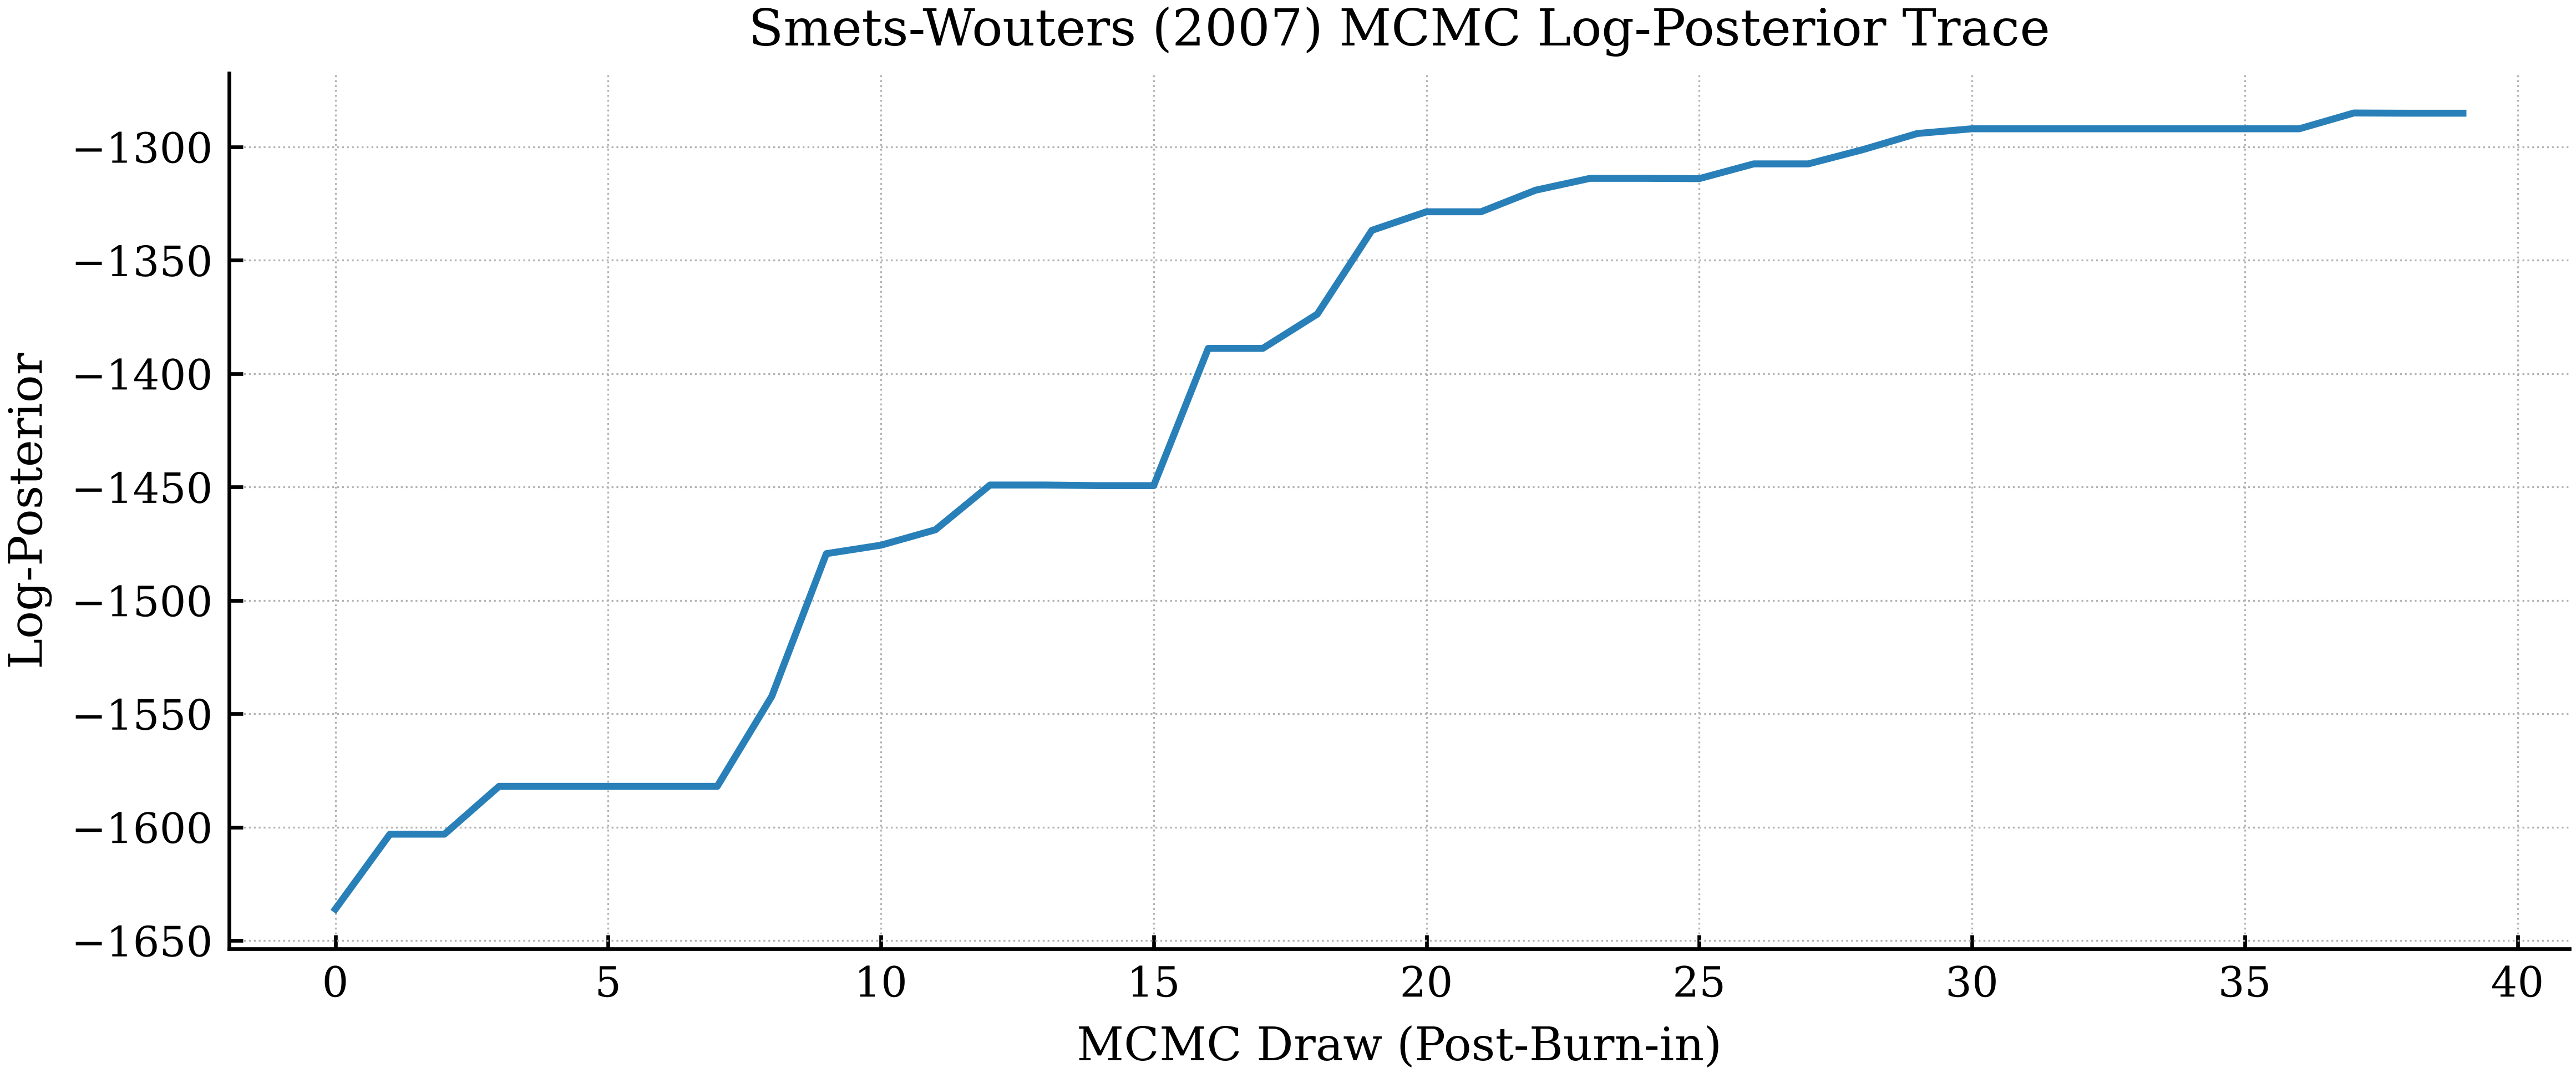

In [7]:
bayes_res = m.estimate(
    data,
    mode_compute="none",
    n_draws=40,
    burn_in=20,
    seed=42,
)

print(bayes_res.summary())

# Plot MCMC trace of the log-posterior
fig_bayes, ax = plt.subplots(figsize=(8, 3.5))
ax.plot(bayes_res.log_posterior_trace[0], color="#2980b9", lw=1.5)
ax.set_xlabel("MCMC Draw (Post-Burn-in)")
ax.set_ylabel("Log-Posterior")
ax.set_title("Smets-Wouters (2007) MCMC Log-Posterior Trace")
plt.tight_layout()
plt.show()

## Conclusion

With `puremacro`:
1. **Zero MATLAB / C++ dependency**: Solve and estimate canonical frontier DSGE models in pure Python.
2. **Dynare Parity**: Load `.mod` files, compute decision rules, theoretical moments, FEVD, historical shock decompositions, OccBin, and perfect foresight.
3. **Anywhere Execution**: Works natively on Apple Silicon, Linux, Windows, JupyterLite, and tablets via WebAssembly.